In [19]:
import pandas as pd


In [20]:
%pip install kagglehub
import kagglehub
import os
# Download latest version
current_dir = os.getcwd()
os.environ["KAGGLEHUB_CACHE"] = current_dir
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: c:\Ironhack\W6\ReviewSense\datasets\datafiniti\consumer-reviews-of-amazon-products\versions\5


In [21]:
data = pd.read_csv("datasets/datafiniti/consumer-reviews-of-amazon-products/versions/5/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")
print(data.head())

                     id             dateAdded           dateUpdated  \
0  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
1  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
2  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
3  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
4  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   

                                                name       asins   brand  \
0  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
1  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
2  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
3  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
4  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   

                                          categories primaryCategories  \
0  Computers,Electronics Features,Tablets,

In [22]:
data.drop(columns=['dateAdded', 'dateUpdated', 'asins', 'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen','reviews.id', 'reviews.username'], inplace=True)
data = data.dropna()
missing_counts = data.isna().sum()
print(missing_counts)

id                     0
name                   0
brand                  0
categories             0
primaryCategories      0
imageURLs              0
keys                   0
manufacturer           0
reviews.doRecommend    0
reviews.numHelpful     0
reviews.rating         0
reviews.sourceURLs     0
reviews.text           0
reviews.title          0
sourceURLs             0
dtype: int64


In [23]:
ratings_map = {5:2,4:2,3:1,2:0,1:0}
data['rating_sentiment'] = data['reviews.rating'].map(ratings_map)
print(data.head())
# data.groupby('rating_sentiment')['reviews.doRecommend'].mean().plot(kind='bar')


                     id                                               name  \
0  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
1  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
2  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
3  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
4  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   

    brand                                         categories  \
0  Amazon  Computers,Electronics Features,Tablets,Electro...   
1  Amazon  Computers,Electronics Features,Tablets,Electro...   
2  Amazon  Computers,Electronics Features,Tablets,Electro...   
3  Amazon  Computers,Electronics Features,Tablets,Electro...   
4  Amazon  Computers,Electronics Features,Tablets,Electro...   

  primaryCategories                                          imageURLs  \
0       Electronics  https://pisces.bbystatic.com/image2/BestBuy_US...  

In [24]:
from sklearn.model_selection import train_test_split
X=data["reviews.text"]
y=data["rating_sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_val.shape}")
print(f"Training output size: {y_train.shape}")
print(f"Testing output size: {y_val.shape}")

Training set size: (3989,)
Testing set size: (998,)
Training output size: (3989,)
Testing output size: (998,)


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Load Tokenizer and Model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
# num_labels=2 for binary classification (pos/neg/neu)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)


train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df = pd.DataFrame({"text": X_val, "label": y_val})
# 2. Convert your DataFrame to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

print(train_dataset[0])

# 3. Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print(tokenized_train[0])

# 4. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,              # 3 epochs is usually enough for fine-tuning
    eval_strategy='epoch',      # Evaluate after each epoch
    learning_rate=2e-5,              # Crucial: use a very small learning rate for fine-tuning
    weight_decay=0.01,
)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}
# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)




tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\charl\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\charl\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'text': 'Bought it for the grandkids for Christmas. Like the parental controls!', 'label': 2}


Map:   0%|          | 0/3989 [00:00<?, ? examples/s]

Map:   0%|          | 0/998 [00:00<?, ? examples/s]

{'text': 'Bought it for the grandkids for Christmas. Like the parental controls!', 'label': 2, 'input_ids': [101, 4149, 2009, 2005, 1996, 2882, 3211, 5104, 2005, 4234, 1012, 2066, 1996, 18643, 7711, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [26]:
# 6. Start Fine-Tuning
trainer.train()

c:\Users\charl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.1783740520477295, 'eval_accuracy': 0.9559118236472945, 'eval_runtime': 4.0143, 'eval_samples_per_second': 248.611, 'eval_steps_per_second': 31.139, 'epoch': 3.0}


In [ ]:
# Get raw predictions
predictions = trainer.predict(tokenized_val)

# Convert raw numbers (logits) to class labels (0, 1, or 2)
predicted_labels = np.argmax(predictions.predictions, axis=1)

# # Compare them to the real labels
# true_labels = predictions.label_ids


# Your code here :
from sklearn.metrics import accuracy_score
print(accuracy_score(y_testset, y_test_pred))
print(accuracy_score(y_trainset, y_train_pred))

In [ ]:
from transformers import pipeline

# Create a classification pipeline using your trained model and tokenizer
# If you didn't save it yet, use trainer.model and trainer.tokenizer
my_test_pipeline = pipeline("sentiment-analysis", model=trainer.model, tokenizer=tokenizer)

# Try a positive review
print(my_test_pipeline("This tablet is amazing, the battery lasts forever!"))

# Try a negative review
print(my_test_pipeline("I hate this product, it broke after two days."))

[{'label': 'LABEL_2', 'score': 0.9983508586883545}]
[{'label': 'LABEL_2', 'score': 0.9964381456375122}]


In [ ]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# best_row    = ens_df.iloc[0]
# best_name   = best_row['Config']
# w42, w0, wsvc, wlr = best_row['weights']
# total_w     = w42 + w0 + wsvc + wlr

# best_probs  = (w42  * probs_s42 +
#                w0   * probs_s0  +
#                wsvc * probs_svc +
#                wlr  * probs_lr) / total_w
# best_preds  = (best_probs[:, 1] >= 0.5).astype(int)

final_acc = accuracy_score(val_df['label'], predicted_labels)
# final_auc = roc_auc_score(val_df['label'], best_probs[:, 1])

# print(f'Best config     : {best_name}')
# print(f'Weights         : seed42={w42}  seed0={w0}  svc={wsvc}  lr={wlr}')
print(f'Final Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)')
# print(f'ROC-AUC         : {final_auc:.4f}')
print()
print(classification_report(val_df['label'], predicted_labels))

print('\nConfusion Matrix:')
print(confusion_matrix(val_df['label'], predicted_labels))

Final Accuracy  : 0.9559  (95.59%)

              precision    recall  f1-score   support

           0       0.75      0.60      0.67        20
           1       0.47      0.22      0.30        36
           2       0.97      0.99      0.98       942

    accuracy                           0.96       998
   macro avg       0.73      0.60      0.65       998
weighted avg       0.95      0.96      0.95       998


Confusion Matrix:
[[ 12   3   5]
 [  2   8  26]
 [  2   6 934]]


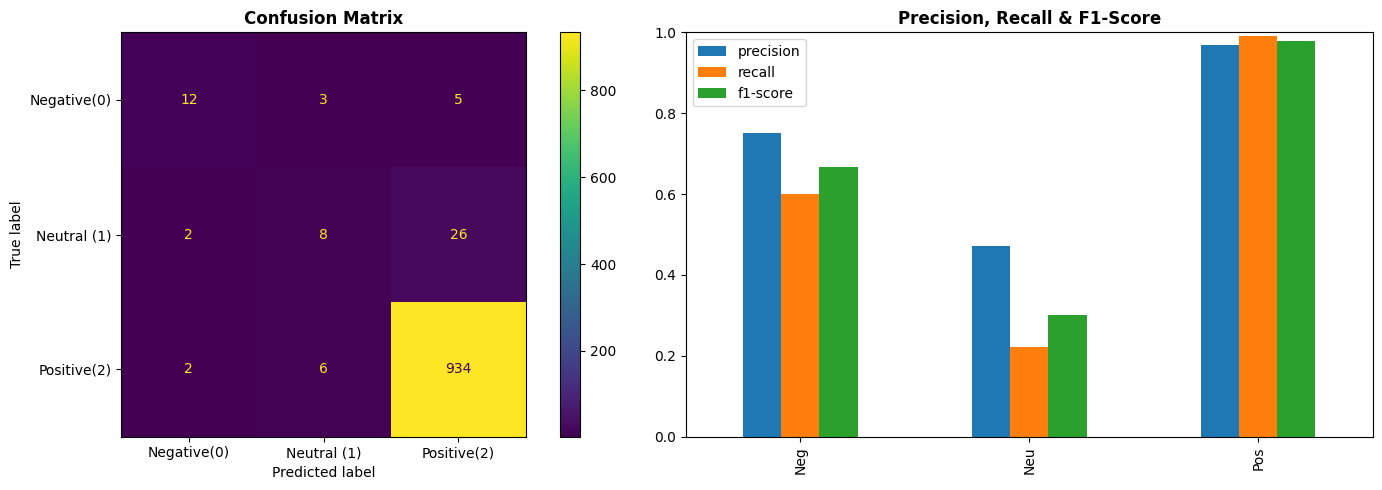

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(val_df['label'], predicted_labels),
    display_labels=['Negative(0)', 'Neutral (1)', "Positive(2)"]
).plot(ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

report = classification_report(val_df['label'], predicted_labels,
                               target_names=['Neg', 'Neu', 'Pos'], output_dict=True)

# Plotting precision, recall, and f1-score on the second axis
pd.DataFrame(report).iloc[:-1, :3].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Precision, Recall & F1-Score', fontweight='bold')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# # Model comparison
# names = ['DistilBERT\nseed=42\n(model4)', 'DistilBERT\nseed=0',
#          'TF-IDF\nSVC', 'TF-IDF\nLogReg', f'Ensemble\n(best)']
# accs  = [acc_s42, acc_s0, acc_svc, acc_lr, final_acc]
# cols  = ['#e67e22', '#f39c12', '#3498db', '#2ecc71', '#e74c3c']

# bars = axes[1].bar(names, accs, color=cols, edgecolor='white', width=0.6)
# for bar, acc in zip(bars, accs):
#     axes[1].text(bar.get_x() + bar.get_width()/2,
#                  bar.get_height() + 0.001,
#                  f'{acc*100:.2f}%', ha='center', fontsize=9, fontweight='bold')

# axes[1].set_ylim(0.90, 1.005)
# axes[1].axhline(0.984, ls='--', color='orange', lw=1.2, label='model4 baseline (98.4%)')
# axes[1].axhline(0.990, ls='--', color='red',    lw=1.2, label='99% target')
# axes[1].set_ylabel('Validation Accuracy')
# axes[1].set_title('Model Comparison', fontweight='bold')
# axes[1].legend(fontsize=8)
# axes[1].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('model6_evaluation.png', dpi=150, bbox_inches='tight')
# plt.show()

The 3 Core IssuesExtreme Class Imbalance: You have 942 positive reviews but only 20 negative and 36 neutral. The model "learned" that if it just guesses "Positive" (2), it gets a 96% accuracy grade.Neutral (1) is a "Ghost": With an F1-score of 0.30, the model is failing on neutrals. Look at the matrix: 26 out of 36 neutrals were misclassified as positive. It hasn't learned the "middle ground."Positive Over-confidence: The recall for Positive is 0.99. It’s basically sucking all the data into the positive category because it doesn't have enough "Negative" examples to know what a complaint looks like.

In [ ]:
train with larger data set??
change params of current model??
downsample positive reviews?


lets try all 3 separately and then TokenClassificationArgumentHandler

EDA IN PC